# Commercial QP solvers — `unfold_gurobi`, `unfold_mosek`, `unfold_cplex`, `unfold_copt`, `unfold_xpress`

The five commercial quadratic-programming backends share one interface
(`unfold_commercial`): a canonical Tikhonov-regularized unfolding QP

$$\min_{\phi \ge 0} \; \|A\phi - b\|_2^2 + \alpha\,\|L\phi\|_2^2$$

solved by cvxpy with a **license-required** engine. None of the engines is
distributed or licensed by bssunfold; if the package or its license is
missing, the method warns and returns a zero spectrum (no open-source
fallback).

## Engine packages and license files (Windows)

| Alias | pip package | License file (default location) |
|-------|-------------|--------------------------------|
| `gurobi` | `gurobipy>=11.0` | `%USERPROFILE%\gurobi.lic` (or `GRB_LICENSE_FILE`) |
| `mosek` | `mosek>=10.1` | `%USERPROFILE%\mosek\mosek.lic` (or `MOSEKLM_LICENSE_FILE`) |
| `cplex` | `cplex>=22.1.0` | none — pip build is the community edition (1000 vars/constraints; enough for 60-bin BSS) |
| `copt` | `coptpy>=8.0` | `%USERPROFILE%\copt.lic` or working directory (or `COPT_LICENSE_FILE`) |
| `xpress` | `xpress>=9.5` | academic community license built in; full license via `xpauth.xpr` + `XPAUTH_PATH` |

Install everything at once:

```bash
pip install "bssunfold[commercial]"
```

In [1]:
# %pip install "bssunfold[commercial]"


## 1. Availability check

`platform_check.check_commercial_solvers_availability()` reports which engines
are importable; `core._commercial_qp.commercial_solver_info()` adds the
cvxpy solver name and the pip package. A solver that is importable but
**unlicensed** still shows as available — the license is only requested by
the engine at solve time.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.platform_check import check_commercial_solvers_availability
from bssunfold.core._commercial_qp import commercial_solver_info
from bssunfold.utils.comparison import compare_spectra

ALIASES = ["gurobi", "mosek", "cplex", "copt", "xpress"]

availability = check_commercial_solvers_availability()
print("Importable engines:", availability)

info = pd.DataFrame([commercial_solver_info(a) for a in ALIASES])
info[['alias', 'pip_package', 'cvxpy_solver', 'available', 'license_required']]

Importable engines: {'gurobi': True, 'mosek': True, 'cplex': True, 'copt': True, 'xpress': True}


,alias,pip_package,cvxpy_solver,available,license_required
0,gurobi,gurobipy,GUROBI,True,True
1,mosek,mosek,MOSEK,True,True
2,cplex,cplex,CPLEX,True,True
3,copt,coptpy,COPT,True,True
4,xpress,xpress,XPRESS,True,True


## 2. Detector and IAEA Compendium readings

Build a `Detector` from the built-in GSF response functions and fold the
chosen IAEA Compendium reference spectrum into detector readings with
`Detector.get_effective_readings_for_spectra` (same setup as the other
IAEA notebooks).

In [3]:
detector = Detector(RF_GSF)
names = detector.detector_names
E = detector.E_MeV
print(detector)

reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra")

spectrum_name = 't4-14-s.txt_1'
readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', spectrum_name]]
)
phi_true = np.interp(E, reference_csv['E_MeV'].values,
                     reference_csv[spectrum_name].values)
print(f"Spectrum: {spectrum_name}; readings for {len(readings)} spheres")

Detector(energy bins: 60, detectors: 10, range: 1.000e-09 - 6.310e+02 MeV)
Reference CSV: 61 rows, 20 spectra
Spectrum: t4-14-s.txt_1; readings for 10 spheres


## 3. Unfold with every available engine

Each `unfold_<alias>` call solves the same QP with its engine. A missing
license surfaces as a `UserWarning` and a **zero spectrum** (the package
never falls back to an open-source solver), so we also flag results whose
spectrum is all-zero.

In [4]:
import warnings

results = {}
rows = []
for alias in ALIASES:
    if not availability[alias]:
        rows.append({"solver": alias, "status": "not installed"})
        continue
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = getattr(detector, f"unfold_{alias}")(readings)
    phi = result["spectrum"]
    if np.all(phi == 0):
        status = "failed (missing license?)"
    else:
        status = "ok"
    results[alias] = result
    rows.append({
        "solver": alias,
        "status": status,
        "warnings": sum("Commercial solver" in str(w.message) for w in caught),
    })

pd.DataFrame(rows)

Restricted license - for non-production use only - expires 2027-11-29


,solver,status,warnings
0,gurobi,ok,0
1,mosek,ok,0
2,cplex,ok,0
3,copt,ok,0
4,xpress,ok,0


## 4. Unfolded spectra vs ground truth

Log-log comparison of the IAEA reference spectrum with the unfolding
results of every engine that returned a non-zero spectrum.

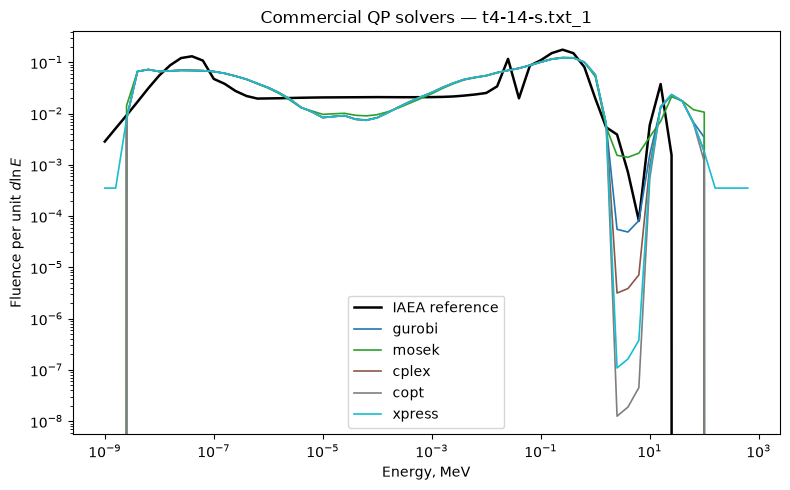

In [5]:
fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.loglog(E, phi_true, 'k-', lw=1.8, label='IAEA reference')
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (alias, result), color in zip(results.items(), colors):
    if np.any(result["spectrum"] > 0):
        ax.loglog(E, result["spectrum"], lw=1.2, color=color, label=alias)
ax.set_xlabel('Energy, MeV')
ax.set_ylabel('Fluence per unit $d\ln E$')
ax.set_title(f'Commercial QP solvers — {spectrum_name}')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Quality metrics and dose rates

`compare_spectra` against the ground truth plus the effective-dose rates
reported by each engine (ICRP-116 coefficients; the dose-integration uses
the per-bin $d\ln E$ widths of the detector grid).

In [6]:
metric_rows = []
for alias, result in results.items():
    if not np.any(result["spectrum"] > 0):
        continue
    metrics = compare_spectra(
        phi_true, result["spectrum"],
        metrics=['relative_flux_error', 'pearson_r',
                 'root_mean_squared_error'],
    )
    metrics['solver'] = alias
    metric_rows.append(metrics)
pd.DataFrame(metric_rows).set_index('solver')

,relative_flux_error,pearson_r,root_mean_squared_error
solver,,,
gurobi,0.422421,0.835398,0.023837
mosek,0.418246,0.839430,0.023601
cplex,0.422592,0.835206,0.023847
copt,0.422640,0.835153,0.023849
xpress,0.422589,0.835261,0.023847


In [7]:
dose_rows = []
for alias, result in results.items():
    if not np.any(result["spectrum"] > 0):
        continue
    dose_rows.append({
        "solver": alias,
        **{g: round(v, 1) for g, v in result["doserates"].items()
           if g in ('AP', 'ISO')},
        "coverage": round(result["dose_coverage_fraction"], 4),
    })
pd.DataFrame(dose_rows).set_index('solver')

,AP,ISO,coverage
solver,,,
gurobi,57.5,30.2,1.0
mosek,59.1,31.9,1.0
cplex,57.3,30.0,1.0
copt,57.2,29.9,1.0
xpress,57.6,30.3,1.0


## 6. Sweep across several IAEA spectra

Repeat the unfolding with the first working engine over a handful of
representative Compendium spectra and report the comprehensive score
(Xu 2026).

In [8]:
working = [a for a, r in results.items() if np.any(r["spectrum"] > 0)]
assert working, "No licensed engine available — place the license files listed above."
solver = working[0]
print(f"Using engine: {solver}")

sweep_columns = ['ISO_ref_Cf252', 'ISO_ref_AmBe',
                 't4-14-s.txt_1', 't4-17-s.txt_1', 't4-19-s.txt_1']
rows = []
for col in sweep_columns:
    r = detector.get_effective_readings_for_spectra(
        reference_csv[['E_MeV', col]]
    )
    res = getattr(detector, f"unfold_{solver}")(r)
    phi_ref = np.interp(E, reference_csv['E_MeV'].values,
                        reference_csv[col].values)
    m = compare_spectra(phi_ref, res['spectrum'],
                        metrics=['relative_flux_error', 'comprehensive_score'])
    rows.append({"spectrum": col, **m})
pd.DataFrame(rows)

Using engine: gurobi


,spectrum,relative_flux_error,comprehensive_score
0,ISO_ref_Cf252,0.068662,-0.430056
1,ISO_ref_AmBe,0.373189,-0.088027
2,t4-14-s.txt_1,0.422421,0.004721
3,t4-17-s.txt_1,0.337079,-0.072303
4,t4-19-s.txt_1,0.562704,0.189858


## 7. Take-aways

- All five engines share one canonical QP and one interface, so switching
  between them is a one-word change (`unfold_gurobi` → `unfold_mosek`, …).
- The same standardized result dictionary is returned (`spectrum`,
  `doserates`, `dose_coverage_fraction`, …), including the new common
  kwargs (`ln_steps`, `reading_uncertainties`, `reading_covariance`,
  `noise_model`, `measurement_time`).
- A missing engine or license degrades to a warning plus a zero spectrum —
  never to a silent open-source fallback, so licence problems are visible.